In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Optimal strategy

This is just using the Bellman equations, matches what we have.

In [3]:
def solve_sheep_game(max_score=100, max_turn=50, max_iterations=100, tolerance=1e-6):
    """
    Solve the Sheep dice game using dynamic programming with Bellman equations.
    
    State: (my_score, opponent_score, turn_total)
    Decision: HOLD or ROLL
    
    Bellman equation:
    V(s1, s2, t) = max(V_hold, V_roll)
    
    where:
    - V_hold = 1 - V(s2, s1+t, 0)  [opponent plays from swapped position]
    - V_roll = sum over outcomes of P(outcome) * V(next_state)
    
    Returns:
        V: value function (win probability) for each state
        policy: optimal action (True=HOLD, False=ROLL) for each state
    """
    
    # V[s1][s2][t] = probability of winning from state (s1, s2, t)
    V = np.zeros((max_score, max_score, max_turn + 1))
    policy = np.zeros((max_score, max_score, max_turn + 1), dtype=bool)
    
    safe_prob = 25/36      # No 6s (5×5 outcomes)
    bust_prob = 10/36      # Exactly one 6 (2×5×2 outcomes)
    disaster_prob = 1/36   # Both 6s (1 outcome)
    
    safe_rolls = []
    for d1 in range(1, 6):
        for d2 in range(1, 6):
            safe_rolls.append(d1 + d2)
    
    print(f"State space: {max_score} * {max_score} * {max_turn+1} = {max_score * max_score * (max_turn+1):,} states")
    
    for iteration in range(max_iterations):
        V_old = V.copy()
        
        for s1 in range(max_score):
            for s2 in range(max_score):
                for t in range(max_turn + 1):
                    
                    # Option 1: HOLD
                    if s1 + t >= max_score:
                        # Win immediately
                        V_hold = 1.0
                    else:
                        # Add turn total to score, opponent plays
                        V_hold = 1.0 - V[s2, min(s1 + t, max_score - 1), 0]
                    
                    
                    # Option 2: ROLL
                    V_roll = 0.0
                    
                    # Case 1: Safe rolls (no 6s) - continue turn
                    for dice_sum in safe_rolls:
                        new_t = min(t + dice_sum, max_turn)
                        V_roll += (1/36) * V[s1, s2, new_t]
                    
                    # Case 2: Bust (exactly one 6) - lose turn
                    V_roll += bust_prob * (1.0 - V[s2, s1, 0])
                    
                    # Case 3: Disaster (two 6s) - lose everything
                    V_roll += disaster_prob * (1.0 - V[s2, 0, 0])
                    
                    # Bellman optimality: choose best action
                    if V_hold >= V_roll:
                        V[s1, s2, t] = V_hold
                        policy[s1, s2, t] = True   # HOLD
                    else:
                        V[s1, s2, t] = V_roll
                        policy[s1, s2, t] = False  # ROLL
        
        max_diff = np.max(np.abs(V - V_old))
        
        if iteration % 10 == 0:
            print(f"  Iteration {iteration:3d}: max_diff = {max_diff:.8f}")
        
        if max_diff < tolerance:
            print(f"Converged after {iteration + 1} iterations (max_diff = {max_diff:.2e})")
            break
    else:
        print(f"Reached max iterations ({max_iterations})")
    
    return V, policy

V, policy = solve_sheep_game()

print(f"\n{'='*70}")
print(f"Win probability from (0,0,0) with optimal play: {V[0, 0, 0]:.6f}")
print(f"{'='*70}")

State space: 100 * 100 * 51 = 510,000 states
  Iteration   0: max_diff = 1.00000000
  Iteration  10: max_diff = 0.05582901
  Iteration  20: max_diff = 0.03011928
  Iteration  30: max_diff = 0.02172496
  Iteration  40: max_diff = 0.01731856
  Iteration  50: max_diff = 0.01242324
  Iteration  60: max_diff = 0.00779939
  Iteration  70: max_diff = 0.00291671
  Iteration  80: max_diff = 0.00080573
  Iteration  90: max_diff = 0.00024463
Reached max iterations (100)

Win probability from (0,0,0) with optimal play: 0.514184


## Naive strategy

Roll the dice exactly once per turn. Hold after that single roll, unless you bust or roll double 6

In [5]:
def roll_once_hold_strategy(my_score, opp_score, turn_total):
    return turn_total > 0

def simulate_game(strategy1, strategy2, max_turns=1000):
    s1, s2 = 0, 0
    turn = 0
    
    stats = {
        'p1': {
            'successful_turns': 0,
            'bust_turns': 0,
            'disaster_turns': 0,
            'total_points_gained': 0,
            'points_per_successful_turn': [],
            'turn_totals': [],
            'disasters_with_score': [],  # Track score when disaster happens
        },
        'p2': {
            'successful_turns': 0,
            'bust_turns': 0,
            'disaster_turns': 0,
            'total_points_gained': 0,
            'points_per_successful_turn': [],
            'turn_totals': [],
            'disasters_with_score': [],
        }
    }
    
    while s1 < 100 and s2 < 100 and turn < max_turns:
        turn += 1
        
        if turn % 2 == 1:
            t = 0
            player_stats = stats['p1']
            
            while True:
                if callable(strategy1):
                    should_hold = strategy1(s1, s2, t)
                else:  # It's the optimal policy array
                    should_hold = strategy1[min(s1, 99), min(s2, 99), min(t, strategy1.shape[2]-1)]
                
                if should_hold and t > 0:
                    s1 += t
                    player_stats['successful_turns'] += 1
                    player_stats['total_points_gained'] += t
                    player_stats['points_per_successful_turn'].append(t)
                    player_stats['turn_totals'].append(t)
                    break
                
                d1, d2 = np.random.randint(1, 7), np.random.randint(1, 7)
                
                if d1 == 6 and d2 == 6:
                    old_s1 = s1
                    s1 = 0
                    player_stats['disaster_turns'] += 1
                    player_stats['turn_totals'].append(-old_s1)  # Lost everything
                    player_stats['disasters_with_score'].append(old_s1)
                    break
                elif d1 == 6 or d2 == 6:
                    player_stats['bust_turns'] += 1
                    player_stats['turn_totals'].append(0)
                    break
                else:
                    t += d1 + d2
        
        else:  # Player 2's turn
            t = 0
            player_stats = stats['p2']
            
            while True:
                if callable(strategy2):
                    should_hold = strategy2(s2, s1, t)
                else:
                    should_hold = strategy2[min(s2, 99), min(s1, 99), min(t, strategy2.shape[2]-1)]
                
                if should_hold and t > 0:
                    s2 += t
                    player_stats['successful_turns'] += 1
                    player_stats['total_points_gained'] += t
                    player_stats['points_per_successful_turn'].append(t)
                    player_stats['turn_totals'].append(t)
                    break
                
                d1, d2 = np.random.randint(1, 7), np.random.randint(1, 7)
                
                if d1 == 6 and d2 == 6:
                    old_s2 = s2
                    s2 = 0
                    player_stats['disaster_turns'] += 1
                    player_stats['turn_totals'].append(-old_s2)
                    player_stats['disasters_with_score'].append(old_s2)
                    break
                elif d1 == 6 or d2 == 6:
                    player_stats['bust_turns'] += 1
                    player_stats['turn_totals'].append(0)
                    break
                else:
                    t += d1 + d2
    
    winner = 1 if s1 >= 100 else 2
    
    return {
        'winner': winner,
        'final_score': (s1, s2),
        'total_turns': turn,
        'stats': stats
    }

In [13]:
print("naive vs naive")
print("\nRunning 10,000 games...")

n_games = 10000
naive_results = []

for i in range(n_games):
    result = simulate_game(roll_once_hold_strategy, roll_once_hold_strategy)
    naive_results.append(result)
    
    if (i + 1) % 2000 == 0:
        print(f"  Completed {i+1:,} games...")

naive vs naive

Running 10,000 games...
  Completed 2,000 games...
  Completed 4,000 games...
  Completed 6,000 games...
  Completed 8,000 games...
  Completed 10,000 games...


In [14]:
print("optimal vs naive")

optimal_results = []

for i in range(n_games):
    result = simulate_game(policy, roll_once_hold_strategy)
    optimal_results.append(result)
    
    if (i + 1) % 2000 == 0:
        print(f"  Completed {i+1:,} games...")

optimal vs naive
  Completed 2,000 games...
  Completed 4,000 games...
  Completed 6,000 games...
  Completed 8,000 games...
  Completed 10,000 games...


In [16]:
def extract_metrics(results, label1="Player 1", label2="Player 2"):
    """Extract all key metrics from simulation results."""
    
    metrics = {
        'p1_wins': sum(1 for r in results if r['winner'] == 1),
        'p2_wins': sum(1 for r in results if r['winner'] == 2),
        'game_lengths': [r['total_turns'] for r in results],
        'final_scores_p1': [r['final_score'][0] for r in results],
        'final_scores_p2': [r['final_score'][1] for r in results],
        'p1_stats': {
            'successful_turns': [r['stats']['p1']['successful_turns'] for r in results],
            'bust_turns': [r['stats']['p1']['bust_turns'] for r in results],
            'disaster_turns': [r['stats']['p1']['disaster_turns'] for r in results],
            'total_points': [r['stats']['p1']['total_points_gained'] for r in results],
            'disasters_with_score': [],
            'points_per_turn': []
        },
        'p2_stats': {
            'successful_turns': [r['stats']['p2']['successful_turns'] for r in results],
            'bust_turns': [r['stats']['p2']['bust_turns'] for r in results],
            'disaster_turns': [r['stats']['p2']['disaster_turns'] for r in results],
            'total_points': [r['stats']['p2']['total_points_gained'] for r in results],
            'disasters_with_score': [],
            'points_per_turn': []
        }
    }
    
    # Collect all points per turn and disasters
    for r in results:
        metrics['p1_stats']['disasters_with_score'].extend(r['stats']['p1']['disasters_with_score'])
        metrics['p1_stats']['points_per_turn'].extend(r['stats']['p1']['points_per_successful_turn'])
        metrics['p2_stats']['disasters_with_score'].extend(r['stats']['p2']['disasters_with_score'])
        metrics['p2_stats']['points_per_turn'].extend(r['stats']['p2']['points_per_successful_turn'])
    
    return metrics

naive_metrics = extract_metrics(naive_results, "Naive P1", "Naive P2")
optimal_metrics = extract_metrics(optimal_results, "Optimal", "Naive")

In [36]:
def print_comparison(naive_m, optimal_m):
    print("naive vs naive")
    
    n1_p1_wins = naive_m['p1_wins']
    n1_p2_wins = naive_m['p2_wins']
    n1_total = n1_p1_wins + n1_p2_wins
    
    print(f"\n Win Distribution:")
    print(f"  Player 1 (first): {n1_p1_wins:,} wins ({n1_p1_wins/n1_total*100:.2f}%)")
    print(f"  Player 2 (second): {n1_p2_wins:,} wins ({n1_p2_wins/n1_total*100:.2f}%)")
    print(f"  First-move advantage: {abs(n1_p1_wins - n1_p2_wins)/n1_total*100:.2f} percentage points")
    
    print(f"\n Game Duration:")
    print(f"  Average: {np.mean(naive_m['game_lengths']):.1f} turns")
    print(f"  Median: {np.median(naive_m['game_lengths']):.0f} turns")
    print(f"  Range: {np.min(naive_m['game_lengths'])}-{np.max(naive_m['game_lengths'])} turns")
    
    print(f"\n Turn Outcomes (per game average):")
    print(f"  Successful: {np.mean(naive_m['p1_stats']['successful_turns']):.1f}")
    print(f"  Busts: {np.mean(naive_m['p1_stats']['bust_turns']):.1f}")
    print(f"  Disasters: {np.mean(naive_m['p1_stats']['disaster_turns']):.2f}")
    
    success_rate = (np.mean(naive_m['p1_stats']['successful_turns']) / 
                   (np.mean(naive_m['p1_stats']['successful_turns']) + 
                    np.mean(naive_m['p1_stats']['bust_turns']) + 
                    np.mean(naive_m['p1_stats']['disaster_turns'])))
    
    print(f"\n Efficiency:")
    print(f"  Success rate: {success_rate*100:.2f}%")
    print(f"  Avg points per success: {np.mean(naive_m['p1_stats']['points_per_turn']):.2f}")
    print(f"  Games with disasters: {sum(1 for r in naive_results if r['stats']['p1']['disaster_turns'] > 0 or r['stats']['p2']['disaster_turns'] > 0)/n1_total*100:.1f}%")
    
    # ========== OPTIMAL VS NAIVE ==========
    print("optimal vs naive")
    
    n2_p1_wins = optimal_m['p1_wins']
    n2_p2_wins = optimal_m['p2_wins']
    n2_total = n2_p1_wins + n2_p2_wins
    
    print(f"\n Win Distribution:")
    print(f"  Optimal: {n2_p1_wins:,} wins ({n2_p1_wins/n2_total*100:.2f}%)")
    print(f"  Naive: {n2_p2_wins:,} wins ({n2_p2_wins/n2_total*100:.2f}%)")
    print(f"  Optimal advantage: {(n2_p1_wins - n2_p2_wins)/n2_total*100:.2f} percentage points")
    print(f"  Win ratio: {n2_p1_wins/n2_p2_wins:.2f}x")
    
    print(f"\n Game Duration:")
    print(f"  Average: {np.mean(optimal_m['game_lengths']):.1f} turns")
    print(f"  Median: {np.median(optimal_m['game_lengths']):.0f} turns")
    
    print(f"\n Scoring Comparison:")
    print(f"  Optimal avg final score: {np.mean(optimal_m['final_scores_p1']):.1f}")
    print(f"  Naive avg final score: {np.mean(optimal_m['final_scores_p2']):.1f}")
    print(f"  Optimal avg points/turn: {np.mean(optimal_m['p1_stats']['points_per_turn']):.2f}")
    print(f"  Naive avg points/turn: {np.mean(optimal_m['p2_stats']['points_per_turn']):.2f}")
    
    
    print(f"\nStrategic Value:")
    improvement = (n2_p1_wins/n2_total - 0.5) * 100
    print(f"  • Optimal strategy improves win rate by {improvement:.1f}pp over random")
    print(f"  • This represents {n2_p1_wins/n2_p2_wins:.2f}x better performance")
    
    print(f"\nEfficiency Gain:")
    efficiency_ratio = np.mean(optimal_m['p1_stats']['points_per_turn']) / np.mean(optimal_m['p2_stats']['points_per_turn'])
    print(f"  • Optimal scores {efficiency_ratio:.2f}x more points per turn")
    print(f"  • {np.mean(optimal_m['p1_stats']['points_per_turn']):.1f} vs {np.mean(optimal_m['p2_stats']['points_per_turn']):.1f} points")
    
    print(f"\nDisaster Impact:")
    all_disasters = len(naive_m['p1_stats']['disasters_with_score']) + len(naive_m['p2_stats']['disasters_with_score'])
    print(f"  • Total disasters in naive games: {all_disasters:,}")
    print(f"  • {sum(1 for r in naive_results if r['stats']['p1']['disaster_turns'] > 0 or r['stats']['p2']['disaster_turns'] > 0)/n1_total*100:.1f}% of games affected")
    if len(naive_m['p1_stats']['disasters_with_score']) > 0:
        print(f"  • Average score lost: {np.mean(naive_m['p1_stats']['disasters_with_score'] + naive_m['p2_stats']['disasters_with_score']):.1f} points")

print_comparison(naive_metrics, optimal_metrics)

naive vs naive

 Win Distribution:
  Player 1 (first): 5,097 wins (50.97%)
  Player 2 (second): 4,903 wins (49.03%)
  First-move advantage: 1.94 percentage points

 Game Duration:
  Average: 51.2 turns
  Median: 47 turns
  Range: 28-172 turns

 Turn Outcomes (per game average):
  Successful: 18.0
  Busts: 7.2
  Disasters: 0.71

 Efficiency:
  Success rate: 69.44%
  Avg points per success: 6.00
  Games with disasters: 69.9%
optimal vs naive

 Win Distribution:
  Optimal: 7,362 wins (73.62%)
  Naive: 2,638 wins (26.38%)
  Optimal advantage: 47.24 percentage points
  Win ratio: 2.79x

 Game Duration:
  Average: 41.2 turns
  Median: 38 turns

 Scoring Comparison:
  Optimal avg final score: 83.9
  Naive avg final score: 64.8
  Optimal avg points/turn: 15.35
  Naive avg points/turn: 6.00

Strategic Value:
  • Optimal strategy improves win rate by 23.6pp over random
  • This represents 2.79x better performance

Efficiency Gain:
  • Optimal scores 2.56x more points per turn
  • 15.4 vs 6.0 poi

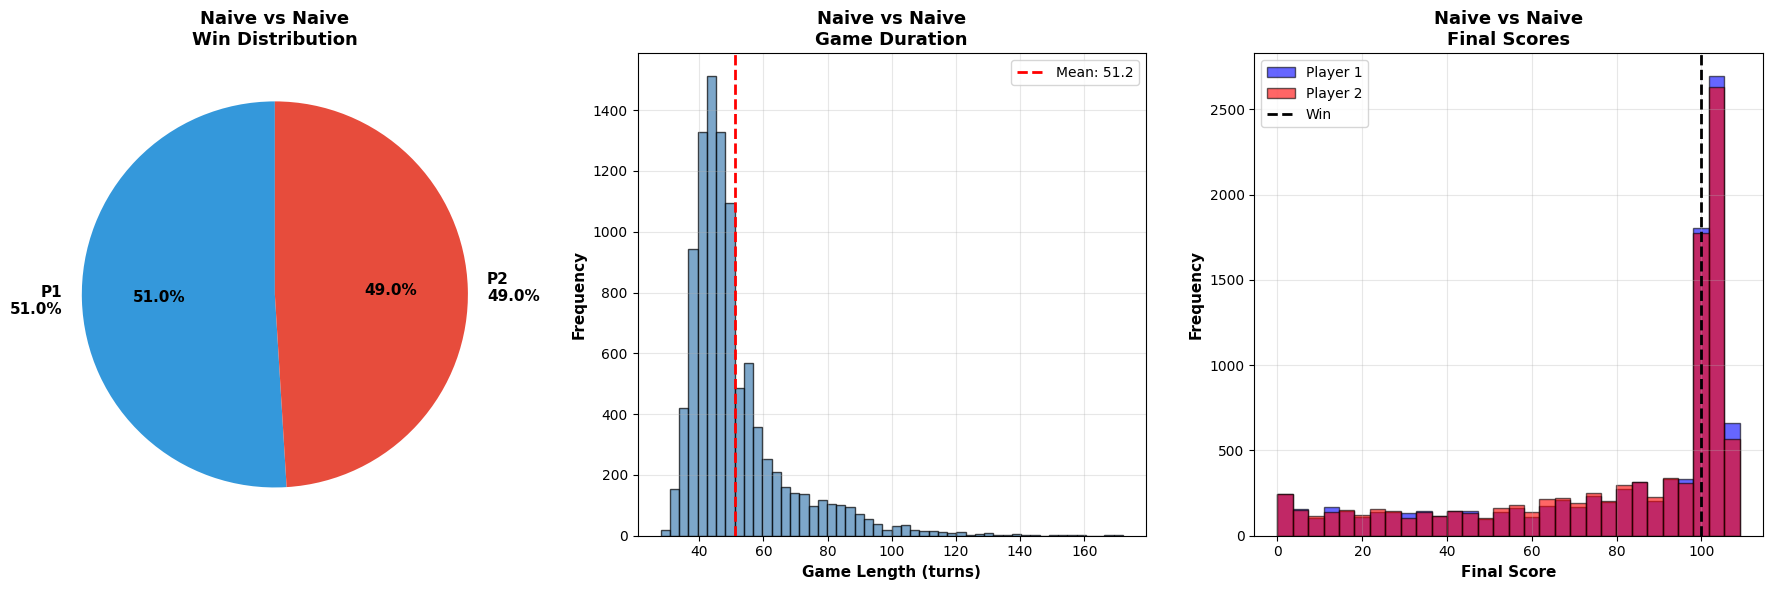

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
n_p1_wins = naive_metrics['p1_wins']
n_p2_wins = naive_metrics['p2_wins']
colors1 = ['#3498db', '#e74c3c']
ax.pie([n_p1_wins, n_p2_wins], 
       labels=[f'P1\n{n_p1_wins/n_games*100:.1f}%', f'P2\n{n_p2_wins/n_games*100:.1f}%'],
       colors=colors1, autopct='%1.1f%%', startangle=90, 
       textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Naive vs Naive\nWin Distribution', fontsize=13, fontweight='bold')

ax = axes[1]
ax.hist(naive_metrics['game_lengths'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(naive_metrics['game_lengths']), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(naive_metrics["game_lengths"]):.1f}')
ax.set_xlabel('Game Length (turns)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Naive vs Naive\nGame Duration', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[2]
ax.hist(naive_metrics['final_scores_p1'], bins=30, alpha=0.6, label='Player 1', 
        color='blue', edgecolor='black')
ax.hist(naive_metrics['final_scores_p2'], bins=30, alpha=0.6, label='Player 2', 
        color='red', edgecolor='black')
ax.axvline(100, color='black', linestyle='--', linewidth=2, label='Win')
ax.set_xlabel('Final Score', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Naive vs Naive\nFinal Scores', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


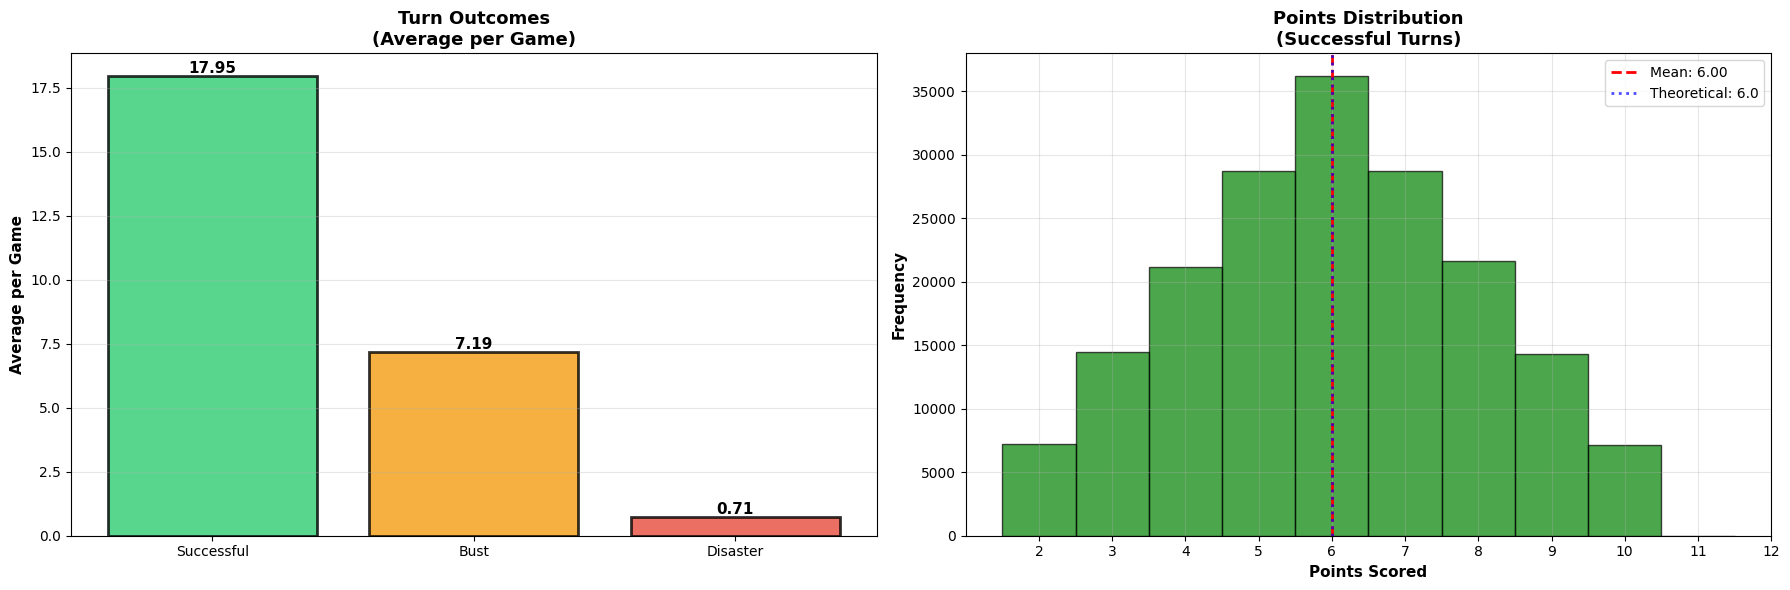

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Turn outcomes breakdown
ax = axes[0]
categories = ['Successful', 'Bust', 'Disaster']
outcomes = [
    np.mean(naive_metrics['p1_stats']['successful_turns']),
    np.mean(naive_metrics['p1_stats']['bust_turns']),
    np.mean(naive_metrics['p1_stats']['disaster_turns'])
]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

bars = ax.bar(categories, outcomes, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
ax.set_ylabel('Average per Game', fontsize=11, fontweight='bold')
ax.set_title('Turn Outcomes\n(Average per Game)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, outcomes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Points distribution per successful turn
ax = axes[1]
points_per_turn = naive_metrics['p1_stats']['points_per_turn']
ax.hist(points_per_turn, bins=range(2, 13), color='green', edgecolor='black', 
        alpha=0.7, align='left')
ax.axvline(np.mean(points_per_turn), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(points_per_turn):.2f}')
ax.axvline(6, color='blue', linestyle=':', linewidth=2, alpha=0.7,
           label='Theoretical: 6.0')
ax.set_xlabel('Points Scored', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Points Distribution\n(Successful Turns)', fontsize=13, fontweight='bold')
ax.set_xticks(range(2, 13))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()